# State Space Modeling - In Progress

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.49503D+00    |proj g|=  8.86184D-02

At iterate    5    f=  2.45154D+00    |proj g|=  1.81041D-01

At iterate   10    f=  1.37662D+00    |proj g|=  4.27081D-01

At iterate   15    f=  8.53990D-01    |proj g|=  9.88758D-01

At iterate   20    f=  7.97207D-01    |proj g|=  2.99604D-02

At iterate   25    f=  7.93977D-01    |proj g|=  2.33802D-02

At iterate   30    f=  7.92915D-01    |proj g|=  5.88714D-03

At iterate   35    f=  7.92851D-01    |proj g|=  1.44462D-03

At iterate   40    f=  7.92847D-01    |proj g|=  8.01676D-04

At iterate   45    f=  7.92847D-01    |proj g|=  4.98247D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = nu

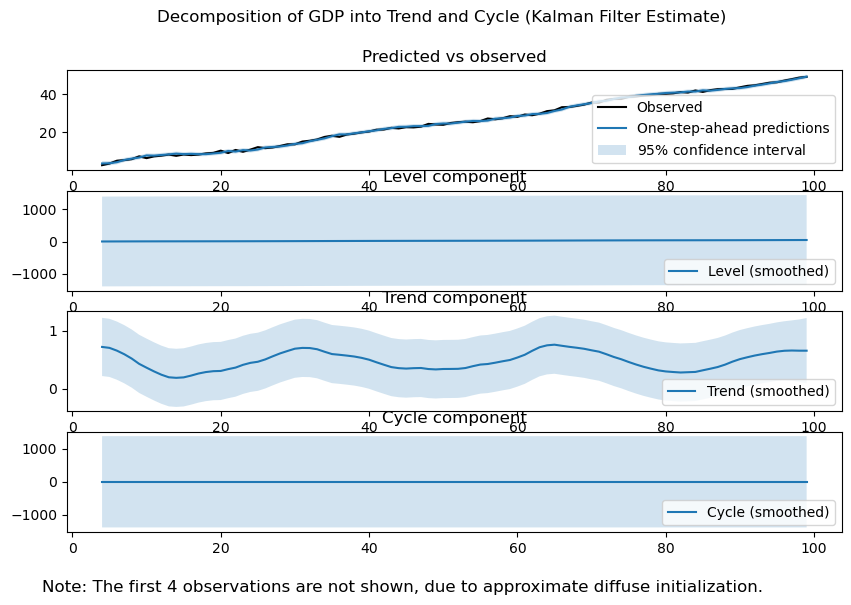

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.structural import UnobservedComponents

#Simulated GDP 
np.random.seed(42)
n = 100
trend = np.cumsum(np.random.normal(0.5, 0.1, n))
cycle = np.sin(np.linspace(0, 6*np.pi, n)) + np.random.normal(0, 0.2, n)
gdp = trend + cycle + np.random.normal(0, 0.3, n)

#State-space model, local linear trend + cycle
mod = UnobservedComponents(gdp, level='local linear trend', cycle=True, stochastic_cycle=True)
res = mod.fit()

#Plot
res.plot_components(legend_loc='lower right', figsize=(10, 6))
plt.suptitle("Decomposition of GDP into Trend and Cycle (Kalman Filter Estimate)")
plt.show()